# Toffoli ladders

In [1]:
from pytket import Circuit
from pytket.circuit.display import render_circuit_jupyter as draw

In [2]:
def toffoli_ladder_circuit(
    n_qubits: int,
    n_anc: int,
    labeled_indices: list[
        tuple[tuple[int, int], tuple[int, int], tuple[int, int]]
    ],
) -> Circuit:
    """Create pytket circuit for a Toffoli ladder.

    Args:
        n_qubits: Number of main/data qubits in register "q".
        n_anc: Number of ancilla qubits in register "a".
        labeled_indices: Triples of qubit references of the form
            ((reg1, i1), (reg2, i2), (reg3, i3)),
            where reg is 0 or 1.

    Returns:
        A pytket Circuit on n_qubits + n_anc qubits, with the first n_qubits
        corresponding to q[0], ..., q[n_qubits-1], and the next n_anc
        corresponding to a[0], ..., a[n_anc-1].
    """
    circuit = Circuit(n_qubits + n_anc)

    def resolve(ref: tuple[str, int]) -> int:
        reg, idx = ref
        if reg == 0:
            if 0 <= idx < n_qubits:
                return idx
            raise IndexError(f"q index out of range: q[{idx}] for n_qubits={n_qubits}")
        if reg == 1:
            if 0 <= idx < n_anc:
                return n_qubits + idx
            raise IndexError(f"a index out of range: a[{idx}] for n_anc={n_anc}")
        raise ValueError(f"Unknown register {reg!r}; expected 'q' or 'a'")

    for c1, c2, t in labeled_indices:
        circuit.CCX(resolve(c1), resolve(c2), resolve(t))

    return circuit

## Linear Toffoli ladder

In [3]:
from guppylang import guppy
from guppyalgos.utils import qarray
from guppyalgos.primitives.subroutines.ladders import ToffoliLadderLinear, ToffoliLadderLog
from guppyalgos.primitives.subroutines.ladders.toffoli_ladder import _lin_toffoli_ladder_indices

def get_linear_circuit(n_qubits: int) -> Circuit:
    indices = _lin_toffoli_ladder_indices(n_qubits)
    labeled_indices = [((0, i), (0, j), (0, k)) for i, j, k in indices]
    circ = toffoli_ladder_circuit(n_qubits, 0, labeled_indices)
    return circ

n_qubits = 9

circ = get_linear_circuit(n_qubits)
draw(circ)

## Log-depth Toffoli ladder

In [4]:
from guppyalgos.primitives.subroutines.ladders.toffoli_ladder import _log_toffoli_ladder_labeled_indices, log_toffoli_ladder_num_ancilla

def get_log_circuit(n_qubits: int) -> Circuit:
    labeled_indices = _log_toffoli_ladder_labeled_indices(n_qubits)
    n_anc = log_toffoli_ladder_num_ancilla(n_qubits)
    circ = toffoli_ladder_circuit(n_qubits, n_anc, labeled_indices)
    return circ

n_qubits = 11

circ = get_log_circuit(n_qubits)
draw(circ)

## Comparing resources

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pytket import Circuit, OpType

def count_toffolis(circ: Circuit) -> int:
    return circ.n_gates_of_type(OpType.CCX)

def toffoli_depth(circ: Circuit) -> int:
    return circ.depth_by_type(OpType.CCX)

def sweep_metrics(
    circ_func,
    n_values: list[int],
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    n_arr = np.array(list(n_values), dtype=float)
    counts = []
    depths = []

    for n in n_arr.astype(int):
        circ = circ_func(n)
        counts.append(count_toffolis(circ))
        depths.append(toffoli_depth(circ))

    return n_arr, np.array(counts, dtype=float), np.array(depths, dtype=float)


def linear_fit(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Fit y = a x + b."""
    a, b = np.polyfit(x, y, 1)
    that = a * x + b
    return np.array([a, b]), that


def log_fit(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Fit y = a log2(x) + b."""
    lx = np.log2(x)
    a, b = np.polyfit(lx, y, 1)
    that = a * lx + b
    return np.array([a, b]), that

In [6]:
impl_name = "ASCENDING_TARGET_BOTTOM"
n_values = range(3, 32, 2)

n_lin, count_lin, depth_lin = sweep_metrics(get_linear_circuit, n_values)
n_log, count_log, depth_log = sweep_metrics(get_log_circuit, n_values)

lin_count_params, lin_count_fit = linear_fit(n_lin, count_lin)
lin_depth_params, lin_depth_fit = linear_fit(n_lin, depth_lin)

log_count_params, log_count_fit = linear_fit(n_log, count_log)
log_depth_params, log_depth_fit = log_fit(n_log, depth_log)

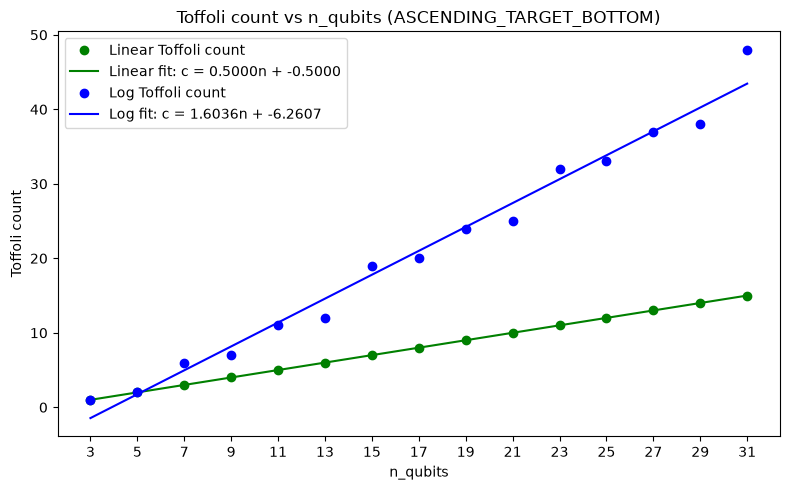

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(n_lin, count_lin, color="g", marker="o", linestyle="None", label="Linear Toffoli count")
plt.plot(n_lin, lin_count_fit, color="g", linestyle="-", label=f"Linear fit: c = {lin_count_params[0]:.4f}n + {lin_count_params[1]:.4f}")

plt.plot(n_log, count_log, color="b", marker="o", linestyle="None", label="Log Toffoli count")
plt.plot(n_log, log_count_fit, color="b", linestyle="-", label=f"Log fit: c = {log_count_params[0]:.4f}n + {log_count_params[1]:.4f}")

plt.xlabel("n_qubits")
plt.ylabel("Toffoli count")
plt.title(f"Toffoli count vs n_qubits ({impl_name})")
plt.legend()
plt.tight_layout()

ax = plt.gca()
odd_ticks = [int(n) for n in n_lin if int(n) % 2 == 1]
ax.set_xticks(odd_ticks)

plt.show()

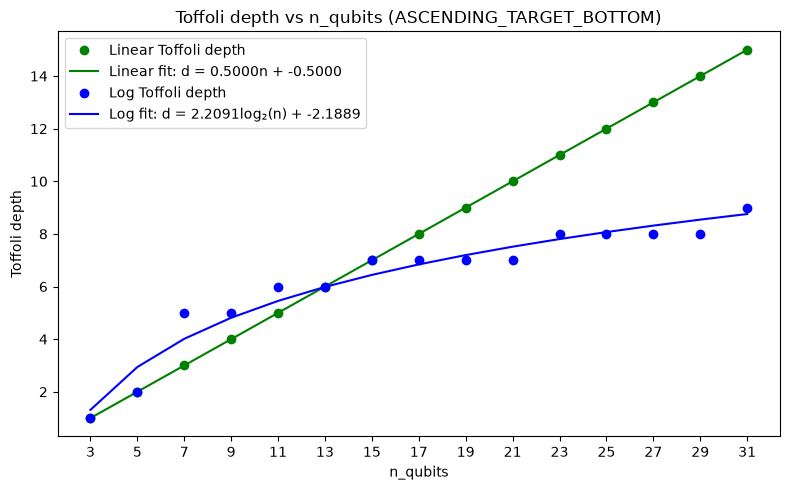

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(n_lin, depth_lin, color="g", marker="o", linestyle="None", label="Linear Toffoli depth")
plt.plot(n_lin, lin_depth_fit, color="g", linestyle="-", label=f"Linear fit: d = {lin_depth_params[0]:.4f}n + {lin_depth_params[1]:.4f}")

plt.plot(n_log, depth_log, color="b", marker="o", linestyle="None", label="Log Toffoli depth")
plt.plot(n_log, log_depth_fit, color="b", linestyle="-", label=f"Log fit: d = {log_depth_params[0]:.4f}log₂(n) + {log_depth_params[1]:.4f}")

plt.xlabel("n_qubits")
plt.ylabel("Toffoli depth")
plt.title(f"Toffoli depth vs n_qubits ({impl_name})")
plt.legend()
plt.tight_layout()

ax = plt.gca()
odd_ticks = [int(n) for n in n_lin if int(n) % 2 == 1]
ax.set_xticks(odd_ticks)

plt.show()

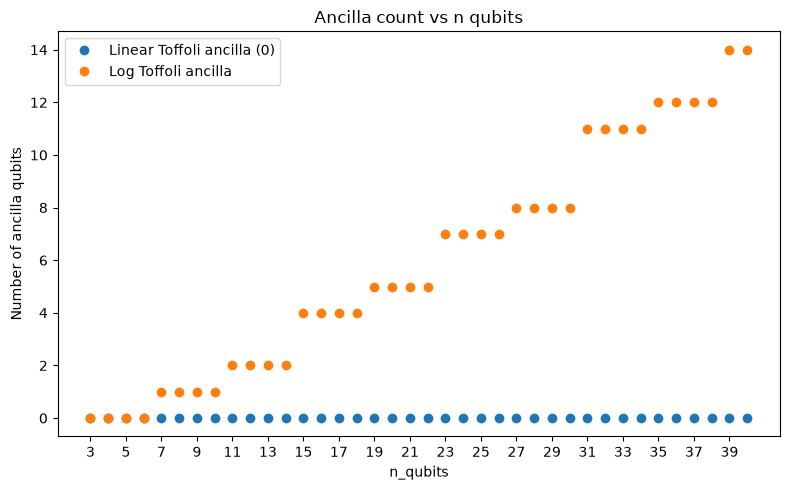

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from guppyalgos.primitives.subroutines.ladders.toffoli_ladder import log_toffoli_ladder_num_ancilla

# Sweep n_qubits
n_values = np.arange(3, 41)

anc_lin = np.array([0 for n in n_values])
anc_log = np.array([log_toffoli_ladder_num_ancilla(int(n)) for n in n_values])

plt.figure(figsize=(8, 5))

plt.plot(n_values, anc_lin, marker="o", linestyle="None", label="Linear Toffoli ancilla (0)")
plt.plot(n_values, anc_log, marker="o", linestyle="None", label="Log Toffoli ancilla")

# Force odd integer ticks
odd_ticks = [int(n) for n in n_values if int(n) % 2 == 1]
plt.xticks(odd_ticks)

plt.xlabel("n_qubits")
plt.ylabel("Number of ancilla qubits")
plt.title("Ancilla count vs n qubits")
plt.legend()
plt.tight_layout()
plt.show()